# Prueba de calculo de Rates

Para esta prueba voy a usar los datos que recolecté usando plot digitalizer por lo tanto pueden ser erroneos o tener leves diferencias con los reales.

Por otro lado usamos la aproximación:

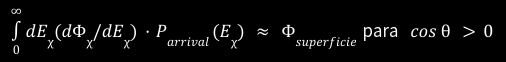

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import simpson
%matplotlib qt

custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

## Datos de flujos 

In [153]:
df_pb = pd.read_csv('Flujo_PB.csv',sep = ';')
df_md = pd.read_csv('Flujo_MD_tot.csv',sep = ';')
masa_pb = df_pb[df_pb.columns[0]]
flujo_pb = df_pb[df_pb.columns[1]]
masa_md = df_md[df_md.columns[0]]
flujo_md = df_md[df_md.columns[1]]


In [128]:
plt.plot(masa_pb, flujo_pb, '-', label='PB')
plt.plot(masa_md, flujo_md, '-', label='MD')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e1,np.max(masa_md))
plt.ylim(np.min(flujo_pb),4e-8)
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Flujo [s⁻¹ cm⁻² sr⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()


Asumo que el flujo en superficie es isotrópico y por lo tanto no depende del ángulo theta para theta menor a $\pi/2$ y solo hay que multiplicar por $2\pi$ para integrar en la semiesfera que estamos considerando.

In [154]:
masa_pb_ = df_pb[df_pb.columns[0]]
flujo_pb_ =2*np.pi*df_pb[df_pb.columns[1]] 
masa_md_ = df_md[df_md.columns[0]]
flujo_md_ =2*np.pi*df_md[df_md.columns[1]]

In [155]:
masa_md = np.logspace(np.log10(np.min(masa_md)),np.log10(np.max(masa_md)),100)
masa_pb = np.logspace(np.log10(np.min(masa_pb)),np.log10(np.max(masa_pb)),100)
flujo_pb_interpolado = interp1d(masa_pb_, flujo_pb_, kind='linear', bounds_error=False, fill_value=0.0)
flujo_md_interpolado = interp1d(masa_md_, flujo_md_, kind='linear', bounds_error=False, fill_value=0.0)
flujo_pb = flujo_pb_interpolado(masa_pb)
flujo_md = flujo_md_interpolado(masa_md)

In [156]:
plt.plot(masa_pb_,flujo_pb_, 'o', label='PB datos')
plt.plot(masa_md_,flujo_md_, 's', label='MD datos')
plt.plot(masa_pb, flujo_pb, '-', label='PB interpolado')
plt.plot(masa_md, flujo_md, '-', label='MD interpolado')
plt.xscale('log')
plt.yscale('log')
plt.legend()

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x58e33f1ab770


# Datos sección eficaz

In [132]:
df_se = pd.read_csv('Seccion_eficaz_DEr_mCP.csv',sep = ';')

In [133]:
Er = df_se[df_se.columns[0]]
sigma_er = df_se[df_se.columns[1]]

In [134]:
plt.plot(Er, sigma_er, '-', label='Sección eficaz')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Sección eficaz diferencial [cm²/eV]')
plt.grid(linestyle='--', alpha=0.5)

Tengo que pasar esta sección eficaz para el caso de que tengamos $\varepsilon = 10^{-2}$

In [135]:
sigma_er = (df_se[df_se.columns[1]]/(1e-6)**2)*(1e-2)**2

In [136]:
len(masa_pb),len(masa_md)

(100, 100)

In [157]:
espectros_pb = np.zeros((len(masa_pb),len(Er)))
espectros_md = np.zeros((len(masa_md),len(Er)))
for i in range(len(masa_pb)):
    espectros_pb[i,:] = flujo_pb[i]*sigma_er

for i in range(len(masa_md)):
    espectros_md[i,:] = flujo_md[i]*sigma_er

In [158]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,5)
masa2 = np.logspace(np.log10(2e2),np.log10(8e2),15)
masa = np.concatenate((masa1,masa2))
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, espectros_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(espectros_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel('Rate [s⁻¹eV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [s⁻¹eV⁻¹]')

Text(0, 0.5, 'Max Rate [s⁻¹eV⁻¹]')

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x58e33f51e810


In [139]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,10)
masa2 = np.logspace(np.log10(2e2),np.log10(1e3),10)
masa = np.concatenate((masa1,masa2))
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, espectros_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(espectros_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel('Rate [s⁻¹eV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [s⁻¹eV⁻¹]')


Text(0, 0.5, 'Max Rate [s⁻¹eV⁻¹]')

In [140]:
mass_md

array([ 10.18939953,  13.10492615,  16.85468204,  21.677368  ,
        27.87998506,  35.85737748,  46.11736758,  59.31308262,
        76.28453128,  98.11207673, 198.48296102, 242.7459648 ,
       282.30827679, 345.26487648, 401.53554107, 491.08060368,
       571.11605999, 698.47869198, 854.24402732, 993.46722206])

In [159]:
plt.plot(mass_pb[mass_pb>400], max_pb[mass_pb>400], '.-')
plt.plot(mass_md[mass_md>400], max_md[mass_md>400], '.-')
plt.xscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Max Rate [s⁻¹eV⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend(['PB','MD'])
plt.show()


qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x58e33b3ddc20


Tenemos que poner el rate diferencial en unidades de DRU

$$
[DRU]= kg^{-1}day^{-1}keV^{-1}
$$

In [160]:
rho_kg = 6.02214076e23/28.0855 # [1/kg]
f_conversion = 8.64e10 # [1/(kg day keV)] ---> [1/(g s eV)]
rate_dif_pb = espectros_pb*rho_kg*(1/f_conversion)
rate_dif_md = espectros_md*rho_kg*(1/f_conversion)

In [161]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,5)
masa2 = np.logspace(np.log10(2e2),np.log10(8e2),15)
masa = np.concatenate((masa1,masa2))
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(rate_dif_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x58e3402e35b0


In [144]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,10)
masa2 = np.logspace(np.log10(2e2),np.log10(1e3),10)
masa = np.concatenate((masa1,masa2))
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(rate_dif_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')


Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x58e33e27c040


In [162]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)

masa = np.logspace(np.log10(50),np.log10(8e2),20)
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(rate_dif_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x58e340826c00


In [146]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)

masa = np.logspace(np.log10(50),np.log10(8e2),20)
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(rate_dif_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

In [163]:
plt.plot(mass_pb, max_pb, '.-')
plt.plot(mass_md, max_md, '.-')
plt.xscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel(f'$ \\frac{{dR}}{{dt}}$ máximo [kg⁻¹day⁻¹keV⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend(['PB','MD'])
plt.show()


qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x58e340cf1d70


In [164]:
plt.plot(Er, rate_dif_pb[0,:], '-', label=f'PB, m={masa[0]:.1f} MeV/c²')
plt.xlim(10,30)
plt.xlabel('Energía de recoil [eV]')
plt.ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

qt.qpa.wayland.textinput: virtual void QtWaylandClient::QWaylandTextInputv3::zwp_text_input_v3_leave(wl_surface*) Got leave event for surface 0x0 with focusing surface 0x58e340f075c0


In [149]:
rate_dif_md.shape

(100, 145)

## **Integrales**

Tenemos que hacer la integral de:

$$
\int_{E_{min}}^{E_{max}} \frac{dR}{dE_r}(E_r)\cdot P_{PC}(E_r) dE_r
$$

Pero como ambos datos no tienen el mismo tamaño hay que hacer una interpolación para que ambos tengan el mismo tamaño.


In [165]:
rate_dif_pb.shape

(100, 145)

In [166]:
path = '/home/lurishi/Escritorio/Doctorado/Data_Er_a_e'
df_PC_1 = pd.read_csv(path+'/1e-.csv',sep = ';')
df_PC_2 = pd.read_csv(path+'/2e-.csv',sep = ';')
df_PC_3 = pd.read_csv(path+'/3e-.csv',sep = ';')
df_PC_4 = pd.read_csv(path+'/4e-.csv',sep = ';')
df_PC_5 = pd.read_csv(path+'/5e-.csv',sep = ';')
df_PC_6 = pd.read_csv(path+'/6e-.csv',sep = ';')
df_PC_7 = pd.read_csv(path+'/7e-.csv',sep = ';')

Er_pc1, Er_pc2, Er_pc3, Er_pc4, Er_pc5, Er_pc6, Er_pc7 = df_PC_1[df_PC_1.columns[0]]/100, df_PC_2[df_PC_2.columns[0]]/100, df_PC_3[df_PC_3.columns[0]]/100, df_PC_4[df_PC_4.columns[0]]/100, df_PC_5[df_PC_5.columns[0]]/100, df_PC_6[df_PC_6.columns[0]]/100, df_PC_7[df_PC_7.columns[0]]/100
P_PC_1,P_PC_2, P_PC_3, P_PC_4, P_PC_5, P_PC_6, P_PC_7 = df_PC_1[df_PC_1.columns[1]], df_PC_2[df_PC_2.columns[1]], df_PC_3[df_PC_3.columns[1]], df_PC_4[df_PC_4.columns[1]], df_PC_5[df_PC_5.columns[1]], df_PC_6[df_PC_6.columns[1]], df_PC_7[df_PC_7.columns[1]]

Er_lista = [Er_pc1, Er_pc2, Er_pc3, Er_pc4, Er_pc5, Er_pc6, Er_pc7]
P_PC_lista = [P_PC_1, P_PC_2, P_PC_3, P_PC_4, P_PC_5, P_PC_6, P_PC_7]

In [173]:
Er_pb_md = Er
rate_integrado_pb = pd.DataFrame(columns = ['masa', '1e','2e','3e','4e','5e','6e','7e'])
rate_integrado_md = pd.DataFrame(columns = ['masa', '1e','2e','3e','4e','5e','6e','7e'])
for i in range(len(masa_pb)):

    rate_pb = np.asarray(rate_dif_pb[i, :], dtype=float)
    rate_md = np.asarray(rate_dif_md[i, :], dtype=float)
    
    fila_pb = []
    fila_md = []
    for j in range(len(Er_lista)):
        Er_pc = Er_lista[j]
        P_PC = P_PC_lista[j]
        Er_pb_md = np.asarray(Er, dtype=float) / 100.0  # keV
        Er_pc = np.asarray(Er_pc, dtype=float)
        E_min = max(Er_pb_md.min(), Er_pc.min())
        E_max = min(Er_pb_md.max(), Er_pc.max())
        if E_min >= E_max:
            integral_pb = 0.0
            integral_md = 0.0
            fila_pb.append(integral_pb)
            fila_md.append(integral_md)
        else:
            E_common = np.linspace(E_min, E_max, 1000)
            f_prob_pc = interp1d(Er_pc, P_PC, kind='linear', bounds_error=False, fill_value=0.0)
            f_rate_pb = interp1d(Er_pb_md, rate_pb, kind='linear', bounds_error=False, fill_value=0.0)
            f_rate_md = interp1d(Er_pb_md, rate_md, kind='linear', bounds_error=False, fill_value=0.0)
            integrand_pb = f_prob_pc(E_common) * f_rate_pb(E_common)
            integrand_md = f_prob_pc(E_common) * f_rate_md(E_common)
            integral_pb = simpson(integrand_pb, E_common)
            integral_md = simpson(integrand_md, E_common)
            fila_pb.append(integral_pb)
            fila_md.append(integral_md)
    rate_integrado_pb.loc[len(rate_integrado_pb)] = [masa_pb[i]] + fila_pb
    rate_integrado_md.loc[len(rate_integrado_md)] = [masa_md[i]] + fila_md



In [177]:
rate_integrado_pb.head()


,masa,1e,2e,3e,4e,5e,6e,7e
0,10.230452,0.0,3.021427e-11,5.115345e-10,1.478024e-09,1.336545e-09,3.349189e-10,2.090797e-11
1,10.693991,0.0,3.022165e-11,5.116594e-10,1.478385e-09,1.336871e-09,3.350007e-10,2.091308e-11
2,11.178534,0.0,3.001210e-11,5.081118e-10,1.468134e-09,1.327602e-09,3.326779e-10,2.076808e-11
3,11.685031,0.0,2.949303e-11,4.993239e-10,1.442742e-09,1.304640e-09,3.269242e-10,2.040889e-11
4,12.214477,0.0,2.947643e-11,4.990428e-10,1.441930e-09,1.303906e-09,3.267401e-10,2.039740e-11


In [179]:
rate_integrado_md.head()

,masa,1e,2e,3e,4e,5e,6e,7e
0,10.189400,0.0,2.688727e-10,4.552077e-09,1.315273e-08,1.189373e-08,2.980398e-09,1.860572e-10
1,10.715336,0.0,2.584884e-10,4.376269e-09,1.264475e-08,1.143438e-08,2.865291e-09,1.788714e-10
2,11.268419,0.0,2.475681e-10,4.191385e-09,1.211055e-08,1.095131e-08,2.744241e-09,1.713147e-10
3,11.850050,0.0,2.361789e-10,3.998563e-09,1.155341e-08,1.044750e-08,2.617994e-09,1.634334e-10
4,12.461703,0.0,2.263605e-10,3.832335e-09,1.107312e-08,1.001318e-08,2.509159e-09,1.566392e-10
